# Model Comparison: 15 Classifiers on HMEQ Loan Default Prediction

This notebook aggregates results from all 15 model notebooks and generates cross-model comparison charts for the Tradeoff Matrix blog.

In [1]:
import sys
sys.path.insert(0, '.')
from shared_utils import *
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    from catboost import CatBoostClassifier
    HAS_CB = True
except ImportError:
    HAS_CB = False

COMP_SLUG = 'comparison'
print('All imports loaded.')

All imports loaded.


In [2]:
# Load data
X_train, X_test, y_train, y_test, df, df_proc, prep_linear, prep_tree, cv, numeric_features, categorical_features, pos_weight = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


## Train All 15 Models and Collect Metrics

We use the same hyperparameters and pipeline structure as each individual notebook but run them all here in one place to ensure an apples-to-apples comparison on the same train/test split.

In [3]:
all_metrics = []
all_scores = {}  # model_name -> y_score array for ROC overlay

def run_model(name, pipeline):
    """Fit pipeline, evaluate, store results."""
    pipeline.fit(X_train, y_train)
    metrics, y_pred, y_score = evaluate_model(name, pipeline, X_test, y_test)
    all_metrics.append(metrics)
    all_scores[name] = y_score
    return metrics

In [4]:
# 1. Logistic Regression
run_model('Logistic Regression', Pipeline([
    ('prep', prep_linear),
    ('clf', LogisticRegression(C=0.1, penalty='l2', class_weight='balanced',
                               max_iter=1000, random_state=RANDOM_STATE)),
]))

# 2. LDA
run_model('LDA', Pipeline([
    ('prep', prep_linear),
    ('clf', LinearDiscriminantAnalysis()),
]))

# 3. QDA
run_model('QDA', Pipeline([
    ('prep', prep_linear),
    ('clf', QuadraticDiscriminantAnalysis()),
]))

# 4. KNN
run_model('KNN', Pipeline([
    ('prep', prep_linear),
    ('clf', KNeighborsClassifier(n_neighbors=11, weights='distance', metric='minkowski', p=2)),
]))

# 5. Naive Bayes
run_model('Gaussian NB', Pipeline([
    ('prep', prep_linear),
    ('clf', GaussianNB()),
]))


  Logistic Regression
  Recall: 0.7845  |  Precision: 0.5782  |  F1: 0.6657
  AUC: 0.8857  |  PR-AUC: 0.7520
  Confusion: TP=233 FP=170 FN=64 TN=1023

  LDA
  Recall: 0.6498  |  Precision: 0.6993  |  F1: 0.6736
  AUC: 0.8838  |  PR-AUC: 0.7484
  Confusion: TP=193 FP=83 FN=104 TN=1110

  QDA
  Recall: 0.6768  |  Precision: 0.4205  |  F1: 0.5187
  AUC: 0.7720  |  PR-AUC: 0.5217
  Confusion: TP=201 FP=277 FN=96 TN=916

  KNN
  Recall: 0.5690  |  Precision: 0.8711  |  F1: 0.6884
  AUC: 0.9219  |  PR-AUC: 0.8221
  Confusion: TP=169 FP=25 FN=128 TN=1168

  Gaussian NB
  Recall: 0.6465  |  Precision: 0.5424  |  F1: 0.5899
  AUC: 0.8206  |  PR-AUC: 0.6023
  Confusion: TP=192 FP=162 FN=105 TN=1031


{'model': 'Gaussian NB',
 'accuracy': 0.8208,
 'precision_1': 0.5424,
 'recall_1': 0.6465,
 'f1_1': 0.5899,
 'roc_auc': 0.8206,
 'pr_auc': 0.6023,
 'cv_score': None,
 'tn': 1031,
 'fp': 162,
 'fn': 105,
 'tp': 192}

In [5]:
# 6. Decision Tree
run_model('Decision Tree', Pipeline([
    ('prep', prep_tree),
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                                    class_weight='balanced', random_state=RANDOM_STATE)),
]))

# 7. Random Forest
run_model('Random Forest', Pipeline([
    ('prep', prep_tree),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10,
                                    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
]))

# 8. Bagging
run_model('Bagging', Pipeline([
    ('prep', prep_tree),
    ('clf', BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE),
        n_estimators=100, max_samples=0.8, max_features=0.8,
        random_state=RANDOM_STATE, n_jobs=-1)),
]))


  Decision Tree
  Recall: 0.8013  |  Precision: 0.5301  |  F1: 0.6381
  AUC: 0.8697  |  PR-AUC: 0.6889
  Confusion: TP=238 FP=211 FN=59 TN=982

  Random Forest
  Recall: 0.7811  |  Precision: 0.6535  |  F1: 0.7117
  AUC: 0.9215  |  PR-AUC: 0.7814
  Confusion: TP=232 FP=123 FN=65 TN=1070

  Bagging
  Recall: 0.6532  |  Precision: 0.7348  |  F1: 0.6916
  AUC: 0.9380  |  PR-AUC: 0.7969
  Confusion: TP=194 FP=70 FN=103 TN=1123


{'model': 'Bagging',
 'accuracy': 0.8839,
 'precision_1': 0.7348,
 'recall_1': 0.6532,
 'f1_1': 0.6916,
 'roc_auc': 0.938,
 'pr_auc': 0.7969,
 'cv_score': None,
 'tn': 1123,
 'fp': 70,
 'fn': 103,
 'tp': 194}

In [6]:
# 9. AdaBoost
run_model('AdaBoost', Pipeline([
    ('prep', prep_tree),
    ('clf', AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
        n_estimators=100, learning_rate=0.1, algorithm='SAMME',
        random_state=RANDOM_STATE)),
]))

# 10. Gradient Boosting
run_model('Gradient Boosting', Pipeline([
    ('prep', prep_tree),
    ('clf', GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1, subsample=0.8,
        min_samples_leaf=20, random_state=RANDOM_STATE)),
]))


  AdaBoost
  Recall: 0.5791  |  Precision: 0.7611  |  F1: 0.6577
  AUC: 0.9075  |  PR-AUC: 0.7807
  Confusion: TP=172 FP=54 FN=125 TN=1139

  Gradient Boosting
  Recall: 0.6970  |  Precision: 0.8554  |  F1: 0.7681
  AUC: 0.9556  |  PR-AUC: 0.8754
  Confusion: TP=207 FP=35 FN=90 TN=1158


{'model': 'Gradient Boosting',
 'accuracy': 0.9161,
 'precision_1': 0.8554,
 'recall_1': 0.697,
 'f1_1': 0.7681,
 'roc_auc': 0.9556,
 'pr_auc': 0.8754,
 'cv_score': None,
 'tn': 1158,
 'fp': 35,
 'fn': 90,
 'tp': 207}

In [7]:
# 11. XGBoost
if HAS_XGB:
    run_model('XGBoost', Pipeline([
        ('prep', prep_tree),
        ('clf', XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss')),
    ]))

# 12. LightGBM
if HAS_LGB:
    run_model('LightGBM', Pipeline([
        ('prep', prep_tree),
        ('clf', LGBMClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1, num_leaves=31,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE, verbose=-1)),
    ]))

# 13. CatBoost
if HAS_CB:
    run_model('CatBoost', Pipeline([
        ('prep', prep_tree),
        ('clf', CatBoostClassifier(
            iterations=200, depth=4, learning_rate=0.1,
            scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE, verbose=0)),
    ]))


  XGBoost
  Recall: 0.8148  |  Precision: 0.7707  |  F1: 0.7921
  AUC: 0.9529  |  PR-AUC: 0.8712
  Confusion: TP=242 FP=72 FN=55 TN=1121

  LightGBM
  Recall: 0.8081  |  Precision: 0.7407  |  F1: 0.7729
  AUC: 0.9444  |  PR-AUC: 0.8567
  Confusion: TP=240 FP=84 FN=57 TN=1109

  CatBoost
  Recall: 0.8182  |  Precision: 0.7232  |  F1: 0.7678
  AUC: 0.9466  |  PR-AUC: 0.8584
  Confusion: TP=243 FP=93 FN=54 TN=1100


In [8]:
# 14. SVM (RBF)
run_model('SVM (RBF)', Pipeline([
    ('prep', prep_linear),
    ('clf', SVC(C=1.0, gamma='scale', kernel='rbf', class_weight='balanced',
                probability=True, random_state=RANDOM_STATE)),
]))

# 15. MLP
run_model('MLP', Pipeline([
    ('prep', prep_linear),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(100, 50), activation='relu', alpha=0.001,
        learning_rate_init=0.01, max_iter=1000, early_stopping=True,
        validation_fraction=0.1, random_state=RANDOM_STATE)),
]))


  SVM (RBF)
  Recall: 0.8215  |  Precision: 0.6404  |  F1: 0.7198
  AUC: 0.9255  |  PR-AUC: 0.8043
  Confusion: TP=244 FP=137 FN=53 TN=1056

  MLP
  Recall: 0.6700  |  Precision: 0.8432  |  F1: 0.7467
  AUC: 0.9234  |  PR-AUC: 0.8412
  Confusion: TP=199 FP=37 FN=98 TN=1156


{'model': 'MLP',
 'accuracy': 0.9094,
 'precision_1': 0.8432,
 'recall_1': 0.67,
 'f1_1': 0.7467,
 'roc_auc': 0.9234,
 'pr_auc': 0.8412,
 'cv_score': None,
 'tn': 1156,
 'fp': 37,
 'fn': 98,
 'tp': 199}

In [9]:
# Build comparison DataFrame
df_comp = pd.DataFrame(all_metrics)
df_comp = df_comp.sort_values('recall_1', ascending=False).reset_index(drop=True)
print(f'\nCollected metrics for {len(df_comp)} models.')
df_comp[['model', 'recall_1', 'precision_1', 'f1_1', 'roc_auc', 'pr_auc', 'accuracy']]


Collected metrics for 15 models.


,model,recall_1,precision_1,f1_1,roc_auc,pr_auc,accuracy
0,SVM (RBF),0.8215,0.6404,0.7198,0.9255,0.8043,0.8725
1,CatBoost,0.8182,0.7232,0.7678,0.9466,0.8584,0.9013
2,XGBoost,0.8148,0.7707,0.7921,0.9529,0.8712,0.9148
3,LightGBM,0.8081,0.7407,0.7729,0.9444,0.8567,0.9054
4,Decision Tree,0.8013,0.5301,0.6381,0.8697,0.6889,0.8188
5,Logistic Regression,0.7845,0.5782,0.6657,0.8857,0.7520,0.8430
6,Random Forest,0.7811,0.6535,0.7117,0.9215,0.7814,0.8738
7,Gradient Boosting,0.6970,0.8554,0.7681,0.9556,0.8754,0.9161
8,QDA,0.6768,0.4205,0.5187,0.7720,0.5217,0.7497
9,MLP,0.6700,0.8432,0.7467,0.9234,0.8412,0.9094


## Chart 1: Recall Rankings

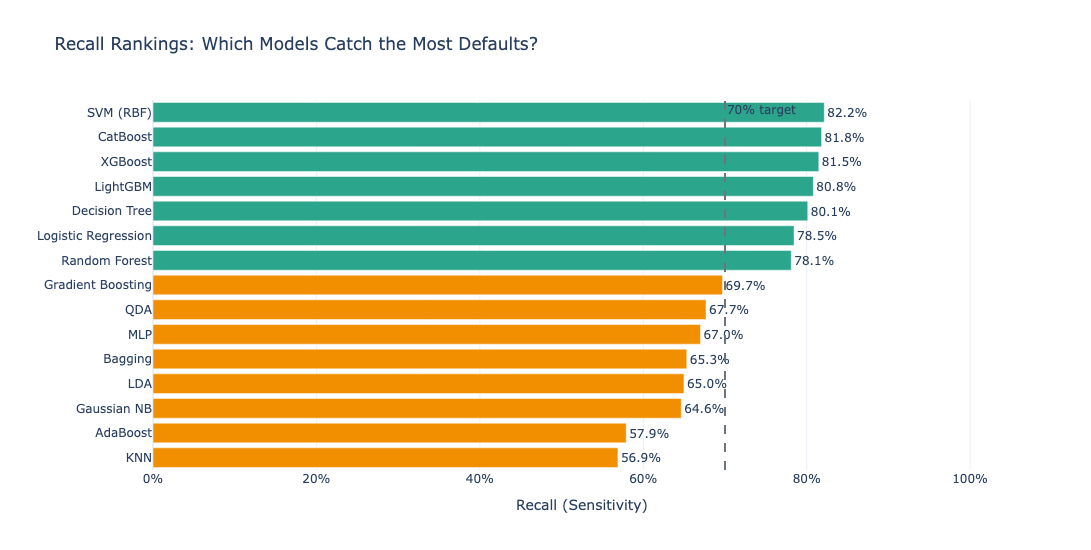

  Saved: outputs/comparison/recall_rankings.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/comparison/recall_rankings.html')

In [10]:
# Recall rankings — horizontal bar chart sorted by recall
df_recall = df_comp.sort_values('recall_1', ascending=True)

fig_recall = go.Figure()
fig_recall.add_trace(go.Bar(
    y=df_recall['model'], x=df_recall['recall_1'],
    orientation='h',
    marker_color=[COLORS['green'] if v >= 0.7 else COLORS['orange'] if v >= 0.5 else COLORS['red']
                  for v in df_recall['recall_1']],
    text=[f'{v:.1%}' for v in df_recall['recall_1']],
    textposition='outside',
))
fig_recall.add_vline(x=0.7, line_dash='dash', line_color=COLORS['gray'],
                     annotation_text='70% target')
fig_recall.update_layout(
    title='Recall Rankings: Which Models Catch the Most Defaults?',
    xaxis_title='Recall (Sensitivity)',
    xaxis=dict(range=[0, 1.05], tickformat='.0%'),
    yaxis_title='',
    height=550, width=750,
    margin=dict(l=140),
    showlegend=False,
)
fig_recall.show()
save_chart(fig_recall, COMP_SLUG, 'recall_rankings')

## Chart 2: Precision Rankings

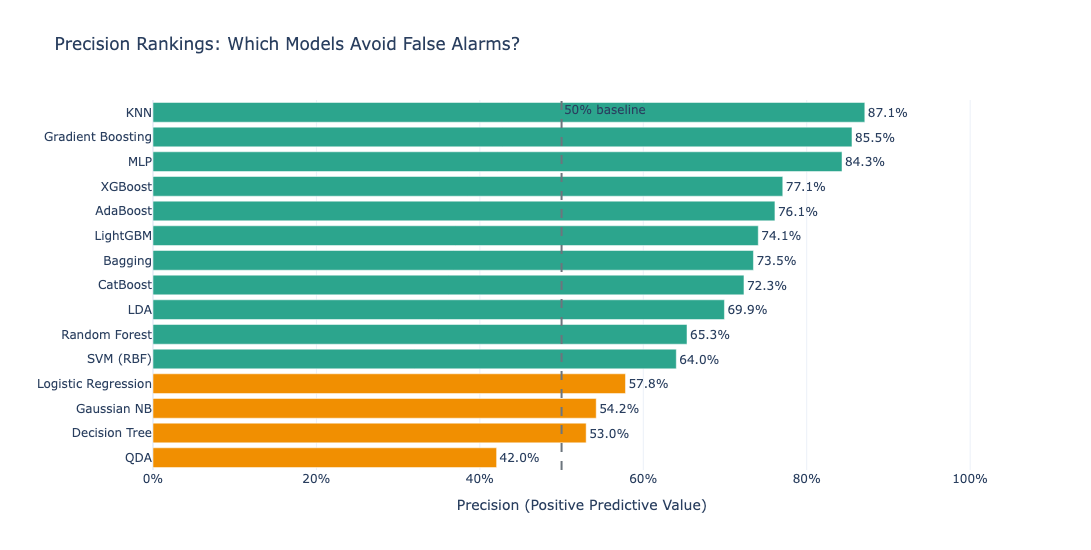

  Saved: outputs/comparison/precision_rankings.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/comparison/precision_rankings.html')

In [11]:
# Precision rankings — horizontal bar chart sorted by precision
df_prec = df_comp.sort_values('precision_1', ascending=True)

fig_prec = go.Figure()
fig_prec.add_trace(go.Bar(
    y=df_prec['model'], x=df_prec['precision_1'],
    orientation='h',
    marker_color=[COLORS['green'] if v >= 0.6 else COLORS['orange'] if v >= 0.4 else COLORS['red']
                  for v in df_prec['precision_1']],
    text=[f'{v:.1%}' for v in df_prec['precision_1']],
    textposition='outside',
))
fig_prec.add_vline(x=0.5, line_dash='dash', line_color=COLORS['gray'],
                   annotation_text='50% baseline')
fig_prec.update_layout(
    title='Precision Rankings: Which Models Avoid False Alarms?',
    xaxis_title='Precision (Positive Predictive Value)',
    xaxis=dict(range=[0, 1.05], tickformat='.0%'),
    yaxis_title='',
    height=550, width=750,
    margin=dict(l=140),
    showlegend=False,
)
fig_prec.show()
save_chart(fig_prec, COMP_SLUG, 'precision_rankings')

## Chart 3: The Tradeoff Scatter (Recall vs Precision)

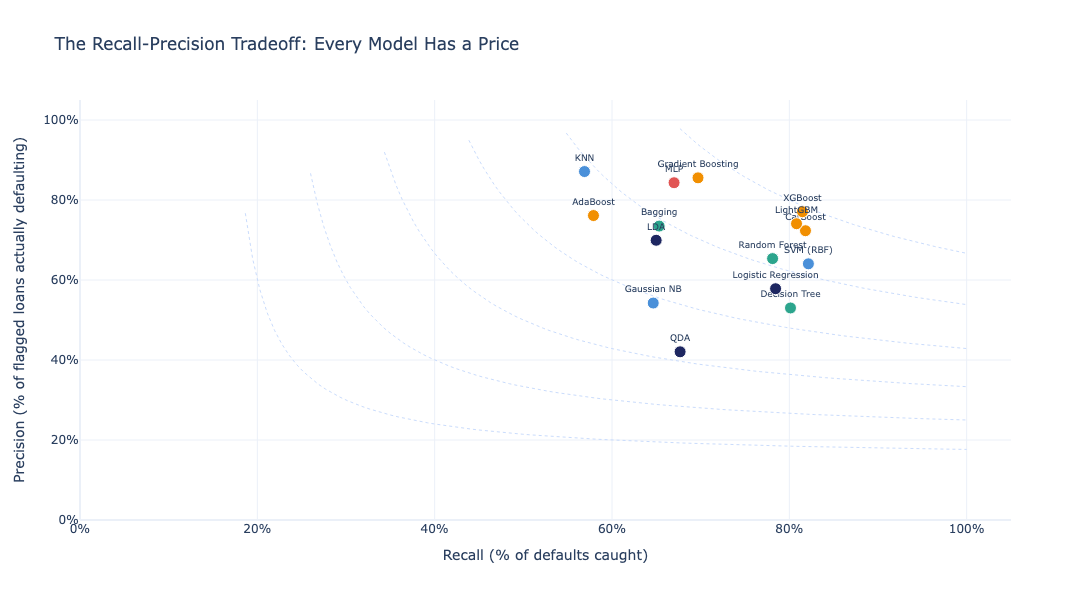

  Saved: outputs/comparison/tradeoff_scatter.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/comparison/tradeoff_scatter.html')

In [12]:
# Scatter plot: recall vs precision with F1 contours
fig_scatter = go.Figure()

# Add F1 iso-curves as background
for f1_val in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    r_range = np.linspace(f1_val / (2 - f1_val) + 0.01, 1.0, 100)
    p_range = (f1_val * r_range) / (2 * r_range - f1_val)
    valid = (p_range > 0) & (p_range <= 1)
    fig_scatter.add_trace(go.Scatter(
        x=r_range[valid], y=p_range[valid],
        mode='lines', name=f'F1={f1_val}',
        line=dict(color=COLORS['ice'], width=1, dash='dot'),
        showlegend=False, hoverinfo='skip',
    ))

# Model family color mapping
family_colors = {
    'Logistic Regression': COLORS['navy'], 'LDA': COLORS['navy'], 'QDA': COLORS['navy'],
    'KNN': COLORS['accent'], 'Gaussian NB': COLORS['accent'], 'SVM (RBF)': COLORS['accent'],
    'Decision Tree': COLORS['green'], 'Random Forest': COLORS['green'],
    'Bagging': COLORS['green'],
    'AdaBoost': COLORS['orange'], 'Gradient Boosting': COLORS['orange'],
    'XGBoost': COLORS['orange'], 'LightGBM': COLORS['orange'], 'CatBoost': COLORS['orange'],
    'MLP': COLORS['red'],
}
family_labels = {
    'Logistic Regression': 'Linear', 'LDA': 'Linear', 'QDA': 'Linear',
    'KNN': 'Distance/Prob', 'Gaussian NB': 'Distance/Prob', 'SVM (RBF)': 'Black Box',
    'Decision Tree': 'Tree', 'Random Forest': 'Bagging', 'Bagging': 'Bagging',
    'AdaBoost': 'Boosting', 'Gradient Boosting': 'Boosting',
    'XGBoost': 'Boosting', 'LightGBM': 'Boosting', 'CatBoost': 'Boosting',
    'MLP': 'Black Box',
}

for _, row in df_comp.iterrows():
    name = row['model']
    fig_scatter.add_trace(go.Scatter(
        x=[row['recall_1']], y=[row['precision_1']],
        mode='markers+text',
        name=name,
        text=[name], textposition='top center', textfont=dict(size=9),
        marker=dict(color=family_colors.get(name, COLORS['gray']), size=12,
                    line=dict(width=1, color='white')),
        hovertemplate=f'<b>{name}</b><br>Recall: {row["recall_1"]:.1%}<br>Precision: {row["precision_1"]:.1%}<br>F1: {row["f1_1"]:.1%}<extra></extra>',
        showlegend=False,
    ))

fig_scatter.update_layout(
    title='The Recall-Precision Tradeoff: Every Model Has a Price',
    xaxis_title='Recall (% of defaults caught)',
    yaxis_title='Precision (% of flagged loans actually defaulting)',
    xaxis=dict(range=[0, 1.05], tickformat='.0%'),
    yaxis=dict(range=[0, 1.05], tickformat='.0%'),
    height=600, width=800,
)
fig_scatter.show()
save_chart(fig_scatter, COMP_SLUG, 'tradeoff_scatter')

## Chart 4: Radar Chart — Multi-Metric Comparison

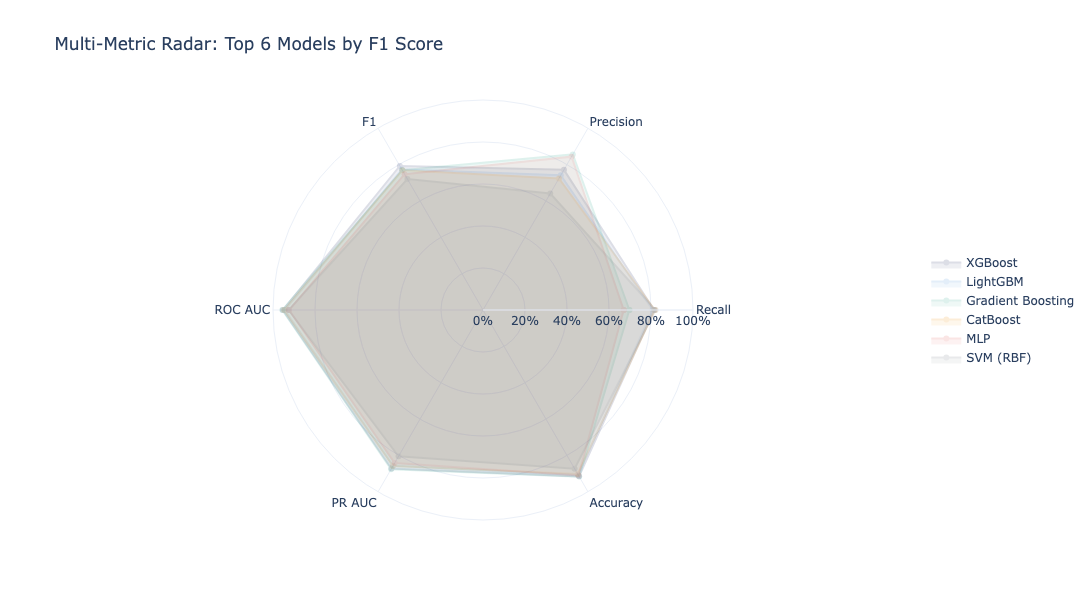

  Saved: outputs/comparison/radar_chart.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/comparison/radar_chart.html')

In [13]:
# Radar chart for top 6 models by F1
radar_metrics = ['recall_1', 'precision_1', 'f1_1', 'roc_auc', 'pr_auc', 'accuracy']
radar_labels = ['Recall', 'Precision', 'F1', 'ROC AUC', 'PR AUC', 'Accuracy']
top6 = df_comp.sort_values('f1_1', ascending=False).head(6)

radar_colors = [COLORS['navy'], COLORS['accent'], COLORS['green'],
                COLORS['orange'], COLORS['red'], COLORS['gray']]

fig_radar = go.Figure()
for i, (_, row) in enumerate(top6.iterrows()):
    values = [row[m] for m in radar_metrics]
    values.append(values[0])  # close the polygon
    fig_radar.add_trace(go.Scatterpolar(
        r=values,
        theta=radar_labels + [radar_labels[0]],
        name=row['model'],
        line=dict(color=radar_colors[i], width=2),
        fill='toself', opacity=0.15,
    ))

fig_radar.update_layout(
    title='Multi-Metric Radar: Top 6 Models by F1 Score',
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1], tickformat='.0%'),
    ),
    height=600, width=700,
    legend=dict(x=1.05, y=0.5),
)
fig_radar.show()
save_chart(fig_radar, COMP_SLUG, 'radar_chart')

## Chart 5: Full Metrics Table

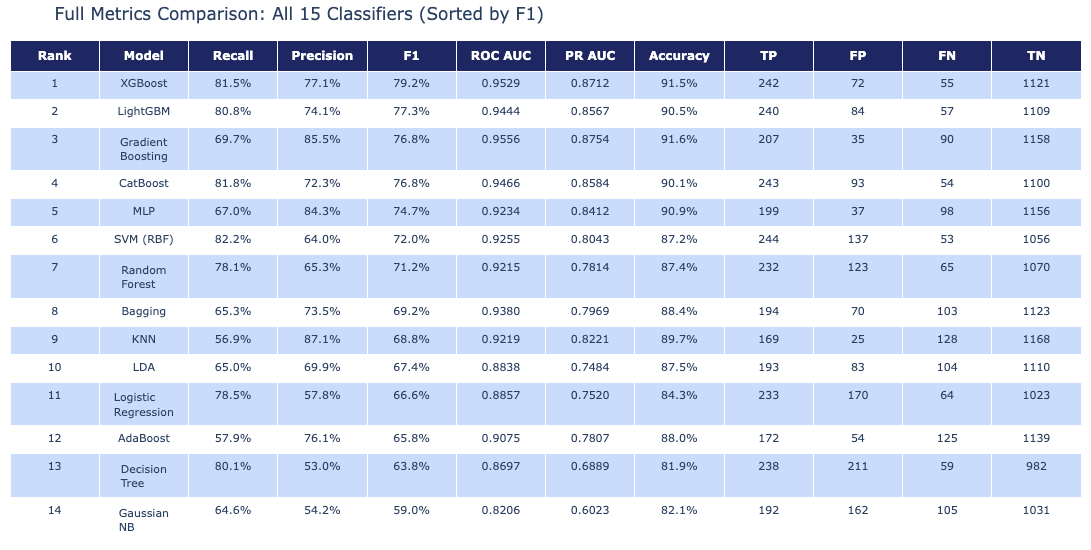

  Saved: outputs/comparison/full_metrics_table.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/comparison/full_metrics_table.html')

In [14]:
# Full comparison table as interactive plotly table
df_table = df_comp.sort_values('f1_1', ascending=False).reset_index(drop=True)

fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>Rank</b>', '<b>Model</b>', '<b>Recall</b>', '<b>Precision</b>',
                '<b>F1</b>', '<b>ROC AUC</b>', '<b>PR AUC</b>', '<b>Accuracy</b>',
                '<b>TP</b>', '<b>FP</b>', '<b>FN</b>', '<b>TN</b>'],
        fill_color=COLORS['navy'],
        font=dict(color='white', size=12),
        align='center',
    ),
    cells=dict(
        values=[
            list(range(1, len(df_table) + 1)),
            df_table['model'],
            [f'{v:.1%}' for v in df_table['recall_1']],
            [f'{v:.1%}' for v in df_table['precision_1']],
            [f'{v:.1%}' for v in df_table['f1_1']],
            [f'{v:.4f}' for v in df_table['roc_auc']],
            [f'{v:.4f}' for v in df_table['pr_auc']],
            [f'{v:.1%}' for v in df_table['accuracy']],
            df_table['tp'], df_table['fp'], df_table['fn'], df_table['tn'],
        ],
        fill_color=[
            [COLORS['ice'] if i % 2 == 0 else 'white' for i in range(len(df_table))]
        ] * 12,
        align='center',
        font=dict(size=11),
        height=28,
    ),
)])
fig_table.update_layout(
    title='Full Metrics Comparison: All 15 Classifiers (Sorted by F1)',
    height=550, width=950,
    margin=dict(l=10, r=10, t=40, b=10),
)
fig_table.show()
save_chart(fig_table, COMP_SLUG, 'full_metrics_table')

## Chart 6: ROC Curve Overlay — All Models

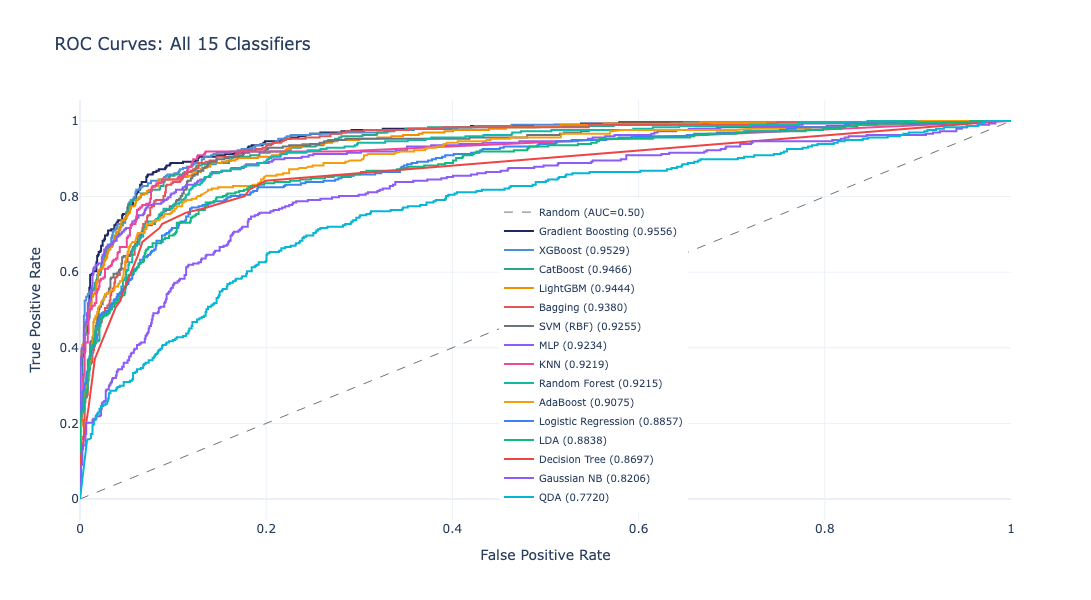

  Saved: outputs/comparison/roc_overlay.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/comparison/roc_overlay.html')

In [15]:
# ROC overlay for all models
roc_colors = [
    '#1E2761', '#4A90D9', '#2CA58D', '#F18F01', '#E15554',
    '#6c757d', '#8B5CF6', '#EC4899', '#14B8A6', '#F59E0B',
    '#3B82F6', '#10B981', '#EF4444', '#8B5CF6', '#06B6D4',
]

fig_roc_all = go.Figure()
fig_roc_all.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1], mode='lines',
    name='Random (AUC=0.50)',
    line=dict(color=COLORS['gray'], width=1, dash='dash'),
))

# Sort by AUC for legend ordering
sorted_models = sorted(all_scores.keys(),
    key=lambda m: roc_auc_score(y_test, all_scores[m]), reverse=True)

for i, name in enumerate(sorted_models):
    fpr, tpr, _ = roc_curve(y_test, all_scores[name])
    auc_val = roc_auc_score(y_test, all_scores[name])
    fig_roc_all.add_trace(go.Scatter(
        x=fpr, y=tpr, mode='lines',
        name=f'{name} ({auc_val:.4f})',
        line=dict(color=roc_colors[i % len(roc_colors)], width=2),
    ))

fig_roc_all.update_layout(
    title='ROC Curves: All 15 Classifiers',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=600, width=800,
    legend=dict(x=0.45, y=0.02, font=dict(size=10)),
)
fig_roc_all.show()
save_chart(fig_roc_all, COMP_SLUG, 'roc_overlay')

## Chart 7: PR Curve Overlay — All Models

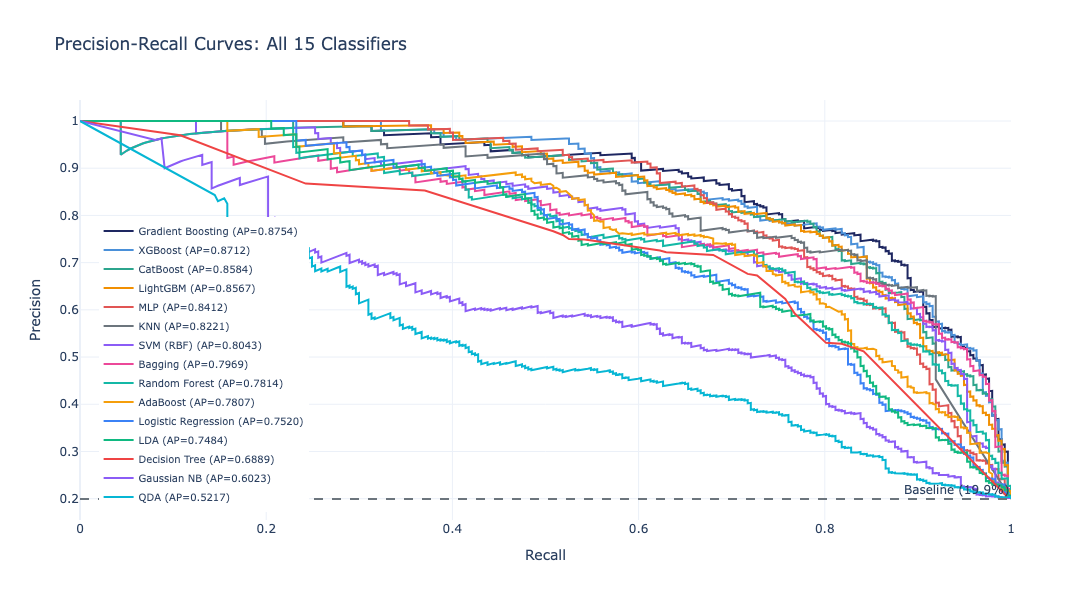

  Saved: outputs/comparison/pr_overlay.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/comparison/pr_overlay.html')

In [16]:
# Precision-Recall overlay
baseline = y_test.mean()

fig_pr_all = go.Figure()
fig_pr_all.add_hline(y=baseline, line_dash='dash', line_color=COLORS['gray'],
                     annotation_text=f'Baseline ({baseline:.1%})')

sorted_pr = sorted(all_scores.keys(),
    key=lambda m: average_precision_score(y_test, all_scores[m]), reverse=True)

for i, name in enumerate(sorted_pr):
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, all_scores[name])
    ap = average_precision_score(y_test, all_scores[name])
    fig_pr_all.add_trace(go.Scatter(
        x=rec_arr, y=prec_arr, mode='lines',
        name=f'{name} (AP={ap:.4f})',
        line=dict(color=roc_colors[i % len(roc_colors)], width=2),
    ))

fig_pr_all.update_layout(
    title='Precision-Recall Curves: All 15 Classifiers',
    xaxis_title='Recall',
    yaxis_title='Precision',
    height=600, width=800,
    legend=dict(x=0.02, y=0.02, font=dict(size=10)),
)
fig_pr_all.show()
save_chart(fig_pr_all, COMP_SLUG, 'pr_overlay')

## Chart 8: Grouped Bar — Recall vs Precision Side by Side

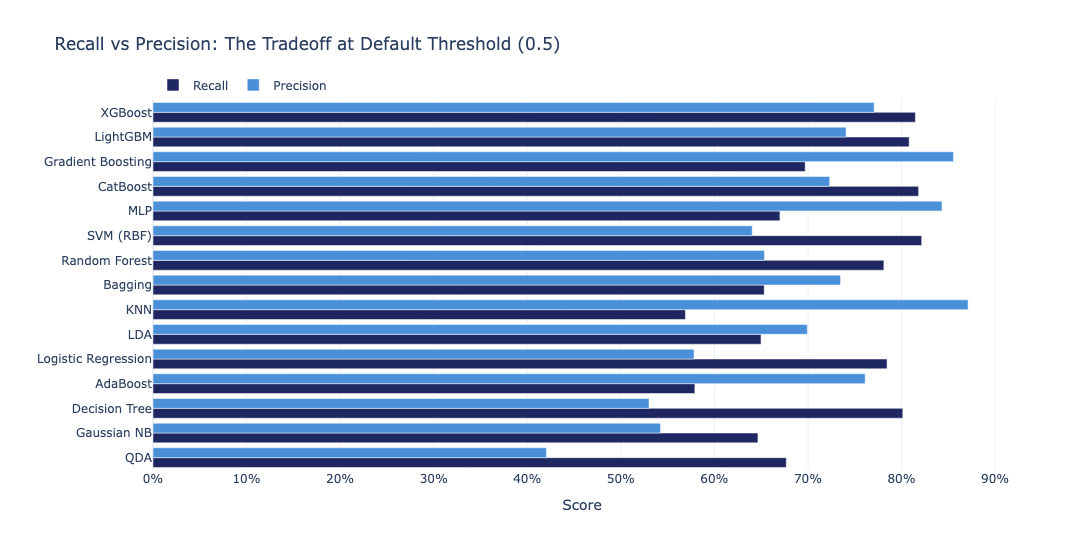

  Saved: outputs/comparison/recall_vs_precision_grouped.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/comparison/recall_vs_precision_grouped.html')

In [17]:
# Grouped bar chart: recall vs precision for all models
df_grouped = df_comp.sort_values('f1_1', ascending=True)

fig_grouped = go.Figure()
fig_grouped.add_trace(go.Bar(
    y=df_grouped['model'], x=df_grouped['recall_1'],
    name='Recall', orientation='h',
    marker_color=COLORS['navy'],
))
fig_grouped.add_trace(go.Bar(
    y=df_grouped['model'], x=df_grouped['precision_1'],
    name='Precision', orientation='h',
    marker_color=COLORS['accent'],
))
fig_grouped.update_layout(
    title='Recall vs Precision: The Tradeoff at Default Threshold (0.5)',
    xaxis_title='Score', xaxis=dict(tickformat='.0%'),
    yaxis_title='',
    barmode='group',
    height=550, width=800,
    margin=dict(l=140),
    legend=dict(orientation='h', y=1.08),
)
fig_grouped.show()
save_chart(fig_grouped, COMP_SLUG, 'recall_vs_precision_grouped')

## Save Metrics CSV for Reference

In [18]:
# Save metrics to CSV for easy reference
out_path = OUTPUT_BASE / COMP_SLUG / 'all_model_metrics.csv'
df_comp.to_csv(out_path, index=False)
print(f'Saved metrics CSV: {out_path}')

# Print final summary
print('\n' + '='*60)
print('  COMPARISON SUMMARY')
print('='*60)
best_recall = df_comp.loc[df_comp['recall_1'].idxmax()]
best_prec = df_comp.loc[df_comp['precision_1'].idxmax()]
best_f1 = df_comp.loc[df_comp['f1_1'].idxmax()]
best_auc = df_comp.loc[df_comp['roc_auc'].idxmax()]

print(f'  Best Recall:    {best_recall["model"]:20s} ({best_recall["recall_1"]:.1%})')
print(f'  Best Precision: {best_prec["model"]:20s} ({best_prec["precision_1"]:.1%})')
print(f'  Best F1:        {best_f1["model"]:20s} ({best_f1["f1_1"]:.1%})')
print(f'  Best ROC AUC:   {best_auc["model"]:20s} ({best_auc["roc_auc"]:.4f})')
print(f'\n  Total charts saved to data/outputs/comparison/')

Saved metrics CSV: /Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/comparison/all_model_metrics.csv

  COMPARISON SUMMARY
  Best Recall:    SVM (RBF)            (82.2%)
  Best Precision: KNN                  (87.1%)
  Best F1:        XGBoost              (79.2%)
  Best ROC AUC:   Gradient Boosting    (0.9556)

  Total charts saved to data/outputs/comparison/
